# Diagonal Covariance EM Fitting — Visual Diagnostics

This notebook shows qualitative examples of how well the diagonal covariance
(`covariance_type='diag'`) Student's t mixture model fits synthetic data.

In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from studenttmixture.em_student_mixture import EMStudentMixture

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 100


def plot_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Plot a 2D covariance ellipse."""
    if cov.shape == (2,):  # diagonal: convert to 2x2
        cov = np.diag(cov)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

## 1. Single Component — Diagonal Fit

Generate 500 samples from a 2D diagonal Student's t (df=4), fit with `covariance_type='diag'`.

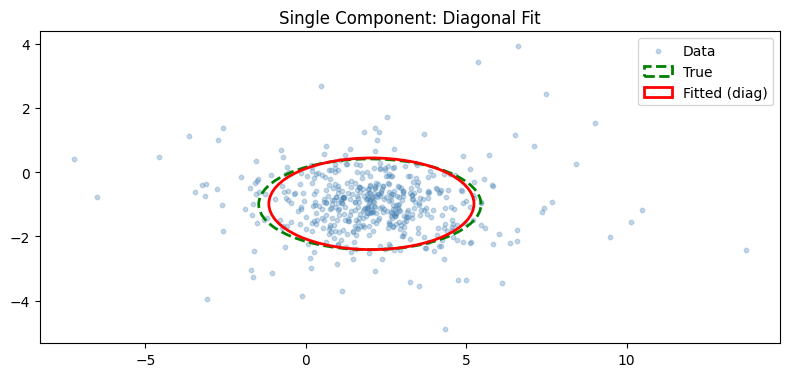

True location:  [ 2. -1.]
Fitted location: [ 2.0484363  -0.98270286]
True variances:  [3.  0.5]
Fitted variances: [2.55314844 0.50971938]
True df: 4.0
Fitted df: 4.02


In [2]:
np.random.seed(42)
true_loc = np.array([2.0, -1.0])
true_var = np.array([3.0, 0.5])
true_cov = np.diag(true_var)
df = 4.0

samples = scipy.stats.multivariate_t.rvs(true_loc, true_cov, df=df, size=500)

model = EMStudentMixture(n_components=1, covariance_type='diag',
        fixed_df=False, max_iter=2000, tol=1e-7)
model.fit(samples)

fig, ax = plt.subplots()
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10, c='steelblue', label='Data')
plot_ellipse(ax, true_loc, true_cov, n_std=2, fill=False,
             edgecolor='green', linewidth=2, linestyle='--', label='True')
plot_ellipse(ax, model.location_.flatten(), model.scale_.flatten(), n_std=2, fill=False,
             edgecolor='red', linewidth=2, label='Fitted (diag)')
ax.legend()
ax.set_title('Single Component: Diagonal Fit')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"True location:  {true_loc}")
print(f"Fitted location: {model.location_.flatten()}")
print(f"True variances:  {true_var}")
print(f"Fitted variances: {model.scale_.flatten()}")
print(f"True df: {df}")
print(f"Fitted df: {model.df_[0]:.2f}")

## 2. Two Components — Diagonal Fit with Cluster Assignments

Two well-separated diagonal clusters. Compare true labels vs fitted predictions.

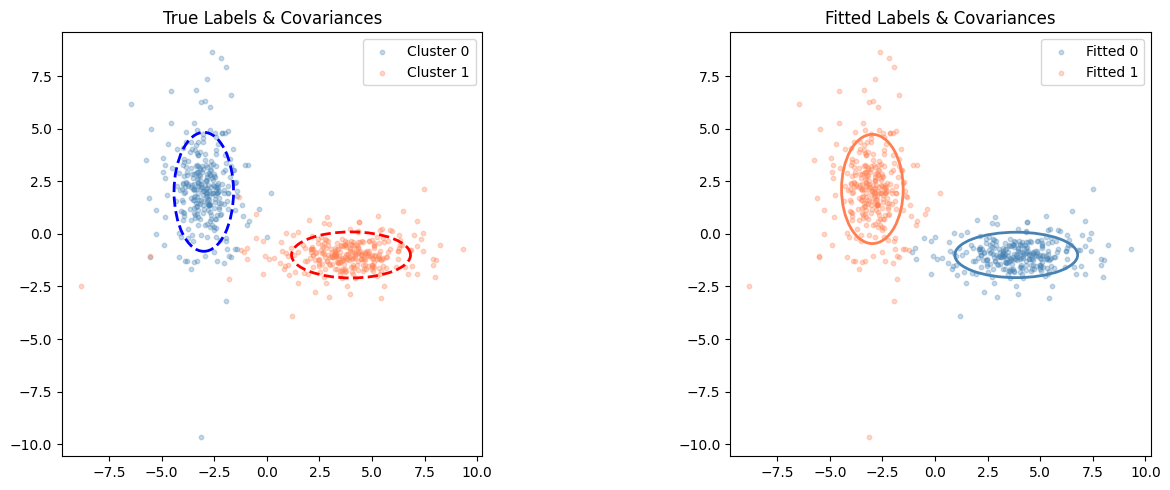

True locations:   [-3.  2.], [ 4. -1.]
Fitted locations: [-2.97855529  2.13659714], [ 3.86178881 -0.99992368]
True variances:   [0.5 2. ], [2.  0.3]
Fitted variances: [0.53696747 1.68497721], [2.13099725 0.29129289]
Fitted mix weights: [0.50478268 0.49521732]


In [3]:
np.random.seed(42)
loc1 = np.array([-3.0, 2.0])
var1 = np.array([0.5, 2.0])
loc2 = np.array([4.0, -1.0])
var2 = np.array([2.0, 0.3])
df = 4.0

s1 = scipy.stats.multivariate_t.rvs(loc1, np.diag(var1), df=df, size=300)
s2 = scipy.stats.multivariate_t.rvs(loc2, np.diag(var2), df=df, size=300)
samples = np.vstack([s1, s2])
true_labels = np.array([0]*300 + [1]*300)

model = EMStudentMixture(n_components=2, covariance_type='diag',
        fixed_df=False, max_iter=2000, tol=1e-7, n_init=3)
model.fit(samples)
pred_labels = model.predict(samples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
ax = axes[0]
ax.scatter(samples[true_labels==0, 0], samples[true_labels==0, 1],
           alpha=0.3, s=10, c='steelblue', label='Cluster 0')
ax.scatter(samples[true_labels==1, 0], samples[true_labels==1, 1],
           alpha=0.3, s=10, c='coral', label='Cluster 1')
plot_ellipse(ax, loc1, np.diag(var1), n_std=2, fill=False,
             edgecolor='blue', linewidth=2, linestyle='--')
plot_ellipse(ax, loc2, np.diag(var2), n_std=2, fill=False,
             edgecolor='red', linewidth=2, linestyle='--')
ax.set_title('True Labels & Covariances')
ax.legend()
ax.set_aspect('equal')

# Fitted labels
ax = axes[1]
colors = ['steelblue', 'coral']
for k in range(2):
    mask = pred_labels == k
    ax.scatter(samples[mask, 0], samples[mask, 1],
               alpha=0.3, s=10, c=colors[k], label=f'Fitted {k}')
    plot_ellipse(ax, model.location_[k], model.scale_[:, k], n_std=2, fill=False,
                 edgecolor=colors[k], linewidth=2)
ax.set_title('Fitted Labels & Covariances')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Sort components for comparison
idx = np.argsort(model.location_[:, 0])
print(f"True locations:   {loc1}, {loc2}")
print(f"Fitted locations: {model.location_[idx[0]]}, {model.location_[idx[1]]}")
print(f"True variances:   {var1}, {var2}")
print(f"Fitted variances: {model.scale_[:, idx[0]]}, {model.scale_[:, idx[1]]}")
print(f"Fitted mix weights: {model.mix_weights_[idx]}")

## 3. Diagonal vs Full — When True Covariance IS Diagonal

When the data is truly diagonal, `'diag'` should fit as well as `'full'` and have lower BIC
(fewer parameters).

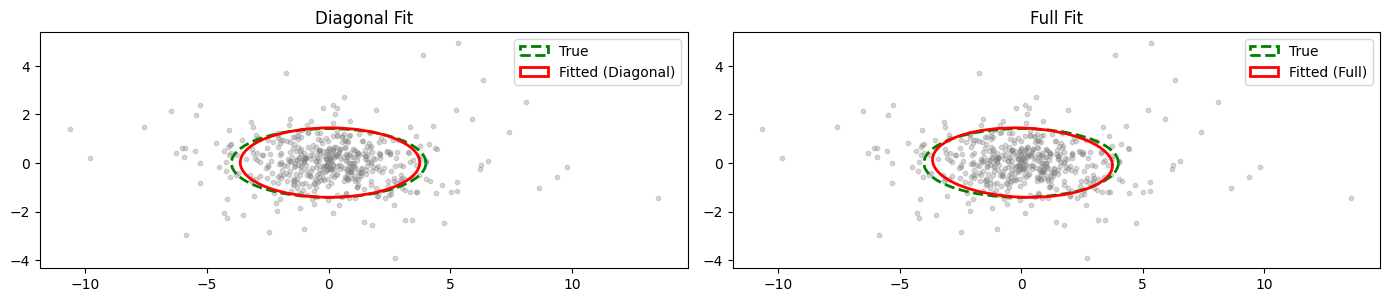

Diagonal BIC: 3642.5
Full BIC:     3646.2
Diagonal wins: True


In [4]:
np.random.seed(42)
true_loc = np.array([0.0, 0.0])
true_var = np.array([4.0, 0.5])
true_cov = np.diag(true_var)
df = 4.0

samples = scipy.stats.multivariate_t.rvs(true_loc, true_cov, df=df, size=500)

model_diag = EMStudentMixture(n_components=1, covariance_type='diag',
        fixed_df=False, max_iter=2000, tol=1e-7)
model_diag.fit(samples)

model_full = EMStudentMixture(n_components=1, covariance_type='full',
        fixed_df=False, max_iter=2000, tol=1e-7)
model_full.fit(samples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in [(axes[0], model_diag, 'Diagonal'),
                          (axes[1], model_full, 'Full')]:
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10, c='gray')
    plot_ellipse(ax, true_loc, true_cov, n_std=2, fill=False,
                 edgecolor='green', linewidth=2, linestyle='--', label='True')
    if title == 'Diagonal':
        cov = model.scale_.flatten()
    else:
        cov = model.scale_[:, :, 0]
    plot_ellipse(ax, model.location_.flatten(), cov, n_std=2, fill=False,
                 edgecolor='red', linewidth=2, label=f'Fitted ({title})')
    ax.legend()
    ax.set_title(f'{title} Fit')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Diagonal BIC: {model_diag.bic(samples):.1f}")
print(f"Full BIC:     {model_full.bic(samples):.1f}")
print(f"Diagonal wins: {model_diag.bic(samples) < model_full.bic(samples)}")

## 4. Diagonal Fit on Non-Diagonal Data (Misspecification)

When the true covariance has off-diagonal elements, the diagonal model cannot capture
the correlation. The fitted ellipse will be axis-aligned while the true one is tilted.

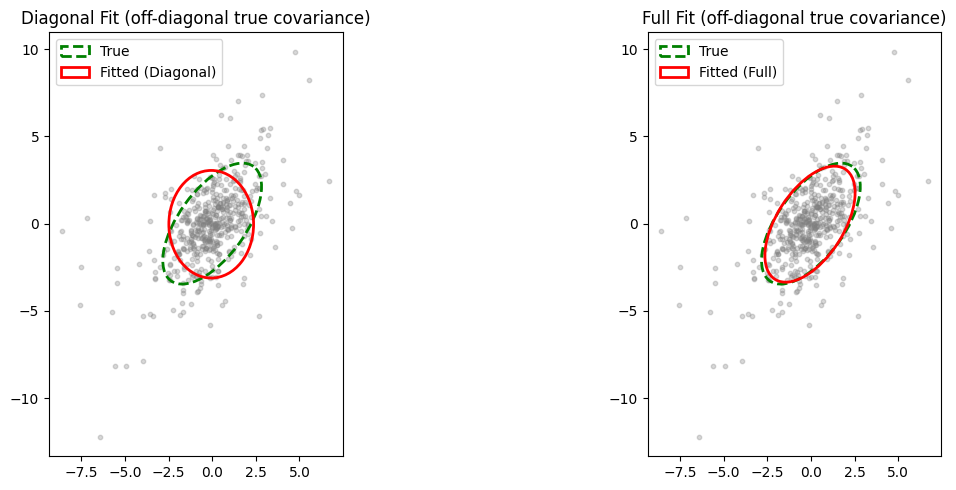

Diagonal BIC: 4088.8
Full BIC:     3960.5
Full wins (as expected): True


In [5]:
np.random.seed(42)
true_loc = np.array([0.0, 0.0])
true_cov = np.array([[2.0, 1.5],
                     [1.5, 3.0]])
df = 4.0

samples = scipy.stats.multivariate_t.rvs(true_loc, true_cov, df=df, size=500)

model_diag = EMStudentMixture(n_components=1, covariance_type='diag',
        fixed_df=False, max_iter=2000, tol=1e-7)
model_diag.fit(samples)

model_full = EMStudentMixture(n_components=1, covariance_type='full',
        fixed_df=False, max_iter=2000, tol=1e-7)
model_full.fit(samples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in [(axes[0], model_diag, 'Diagonal'),
                          (axes[1], model_full, 'Full')]:
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10, c='gray')
    plot_ellipse(ax, true_loc, true_cov, n_std=2, fill=False,
                 edgecolor='green', linewidth=2, linestyle='--', label='True')
    if title == 'Diagonal':
        cov = model.scale_.flatten()
    else:
        cov = model.scale_[:, :, 0]
    plot_ellipse(ax, model.location_.flatten(), cov, n_std=2, fill=False,
                 edgecolor='red', linewidth=2, label=f'Fitted ({title})')
    ax.legend()
    ax.set_title(f'{title} Fit (off-diagonal true covariance)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Diagonal BIC: {model_diag.bic(samples):.1f}")
print(f"Full BIC:     {model_full.bic(samples):.1f}")
print(f"Full wins (as expected): {model_full.bic(samples) < model_diag.bic(samples)}")

## 5. High-Dimensional Variance Recovery

For M=10, 50, 100 dimensions: fit a single diagonal component and compare
true vs fitted per-dimension variances.

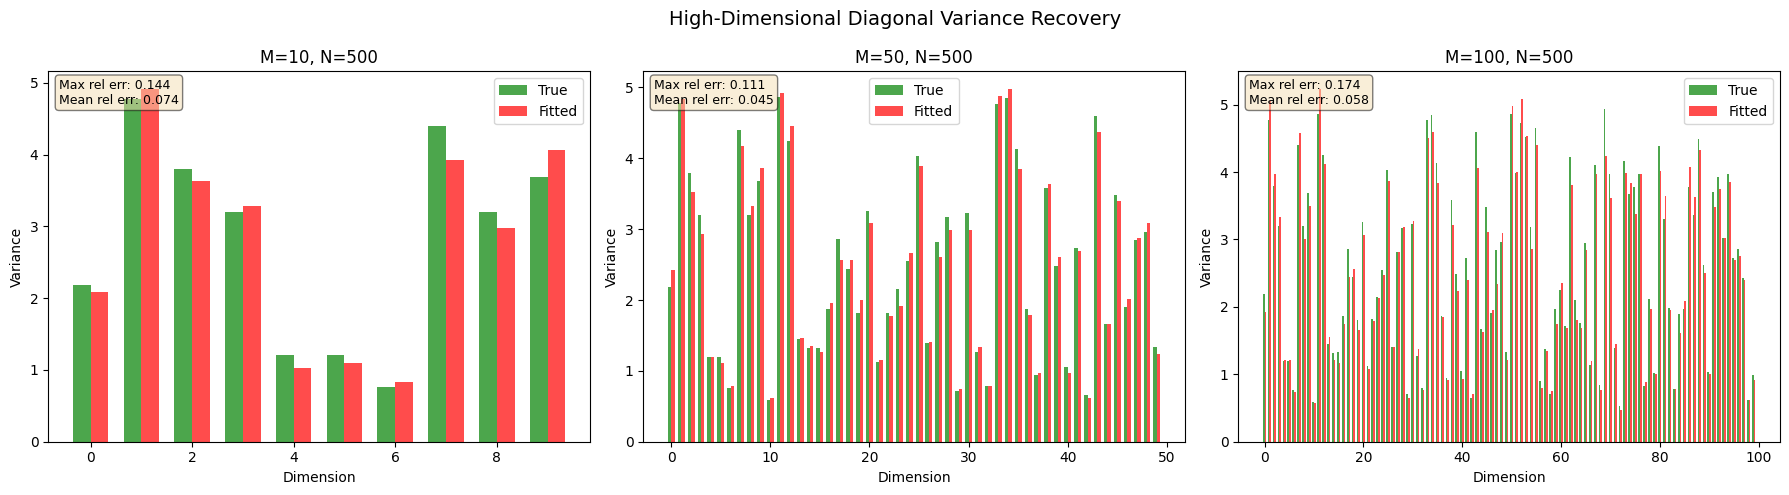

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, M in zip(axes, [10, 50, 100]):
    np.random.seed(42)
    true_var = np.random.uniform(0.5, 5.0, M)
    true_loc = np.random.uniform(-3.0, 3.0, M)
    df = 4.0
    N = max(500, 5 * M)

    samples = scipy.stats.multivariate_t.rvs(true_loc, np.diag(true_var), df=df, size=N)

    model = EMStudentMixture(n_components=1, covariance_type='diag',
            fixed_df=False, max_iter=2000, tol=1e-7)
    model.fit(samples)

    fit_var = model.scale_.flatten()
    dims = np.arange(M)
    width = 0.35

    ax.bar(dims - width/2, true_var, width, alpha=0.7, color='green', label='True')
    ax.bar(dims + width/2, fit_var, width, alpha=0.7, color='red', label='Fitted')
    ax.set_title(f'M={M}, N={N}')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Variance')
    ax.legend()

    max_rel_err = np.max(np.abs(fit_var - true_var) / true_var)
    mean_rel_err = np.mean(np.abs(fit_var - true_var) / true_var)
    ax.text(0.02, 0.98, f'Max rel err: {max_rel_err:.3f}\nMean rel err: {mean_rel_err:.3f}',
            transform=ax.transAxes, verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('High-Dimensional Diagonal Variance Recovery', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Ten Components — Exact Match (2D)

Generate 10 well-separated 2D diagonal clusters on a grid. Fit with K=10.

/var/folders/_m/ssv11vnn7r56s_6gwfh_dh6r0000gn/T/ipykernel_96024/589018930.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K_true)


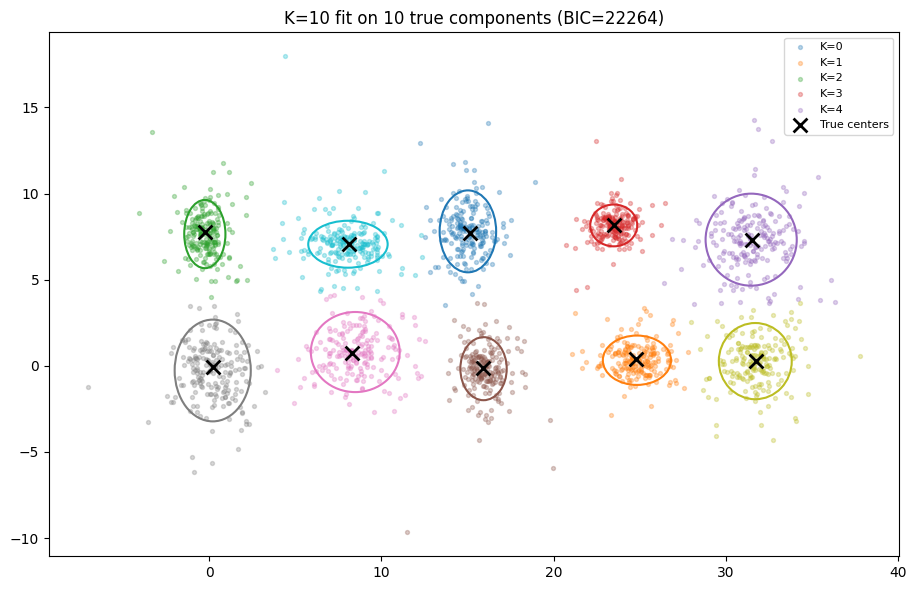

Active components (weight > 1%): 10/10
Mix weights: [0.106 0.102 0.102 0.1   0.1   0.1   0.099 0.098 0.097 0.096]


In [7]:
np.random.seed(42)
K_true = 10
df = 4.0
N_per = 200

# Place 10 centers on a 2x5 grid with spacing=8
grid_x = np.arange(5) * 8.0
grid_y = np.arange(2) * 8.0
true_locs = np.array([[x, y] for y in grid_y for x in grid_x])  # 10 x 2
true_locs += np.random.randn(K_true, 2) * 0.5  # small perturbation
true_vars = np.random.uniform(0.3, 2.0, (2, K_true))  # M x K

# Generate data
all_samples = []
for k in range(K_true):
    s = scipy.stats.multivariate_t.rvs(true_locs[k], np.diag(true_vars[:, k]),
                                        df=df, size=N_per)
    all_samples.append(s)
samples_10 = np.vstack(all_samples)

# Fit with exact K
model_10 = EMStudentMixture(n_components=K_true, covariance_type='diag',
        fixed_df=False, max_iter=3000, tol=1e-7, n_init=3, random_state=42)
model_10.fit(samples_10)

pred = model_10.predict(samples_10)

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.get_cmap('tab10', K_true)
for k in range(K_true):
    mask = pred == k
    ax.scatter(samples_10[mask, 0], samples_10[mask, 1], alpha=0.3, s=8,
               c=[cmap(k)], label=f'K={k}' if k < 5 else None)
    plot_ellipse(ax, model_10.location_[k], model_10.scale_[:, k], n_std=2,
                 fill=False, edgecolor=cmap(k), linewidth=1.5)

# Overlay true centers
ax.scatter(true_locs[:, 0], true_locs[:, 1], marker='x', c='black',
           s=100, linewidths=2, label='True centers')
ax.set_title(f'K=10 fit on 10 true components (BIC={model_10.bic(samples_10):.0f})')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

active = np.sum(model_10.mix_weights_ > 0.01)
print(f"Active components (weight > 1%): {active}/{K_true}")
print(f"Mix weights: {np.sort(model_10.mix_weights_)[::-1].round(3)}")

## 7. Ten True Modes — Over-specified K=15, 20, 25 (2D)

Same 10-component data, fit with more components than needed.
Extra components should get near-zero weight or collapse onto existing clusters.

/var/folders/_m/ssv11vnn7r56s_6gwfh_dh6r0000gn/T/ipykernel_96024/3773212436.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K_fit)
/var/folders/_m/ssv11vnn7r56s_6gwfh_dh6r0000gn/T/ipykernel_96024/3773212436.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K_fit)
/var/folders/_m/ssv11vnn7r56s_6gwfh_dh6r0000gn/T/ipykernel_96024/3773212436.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

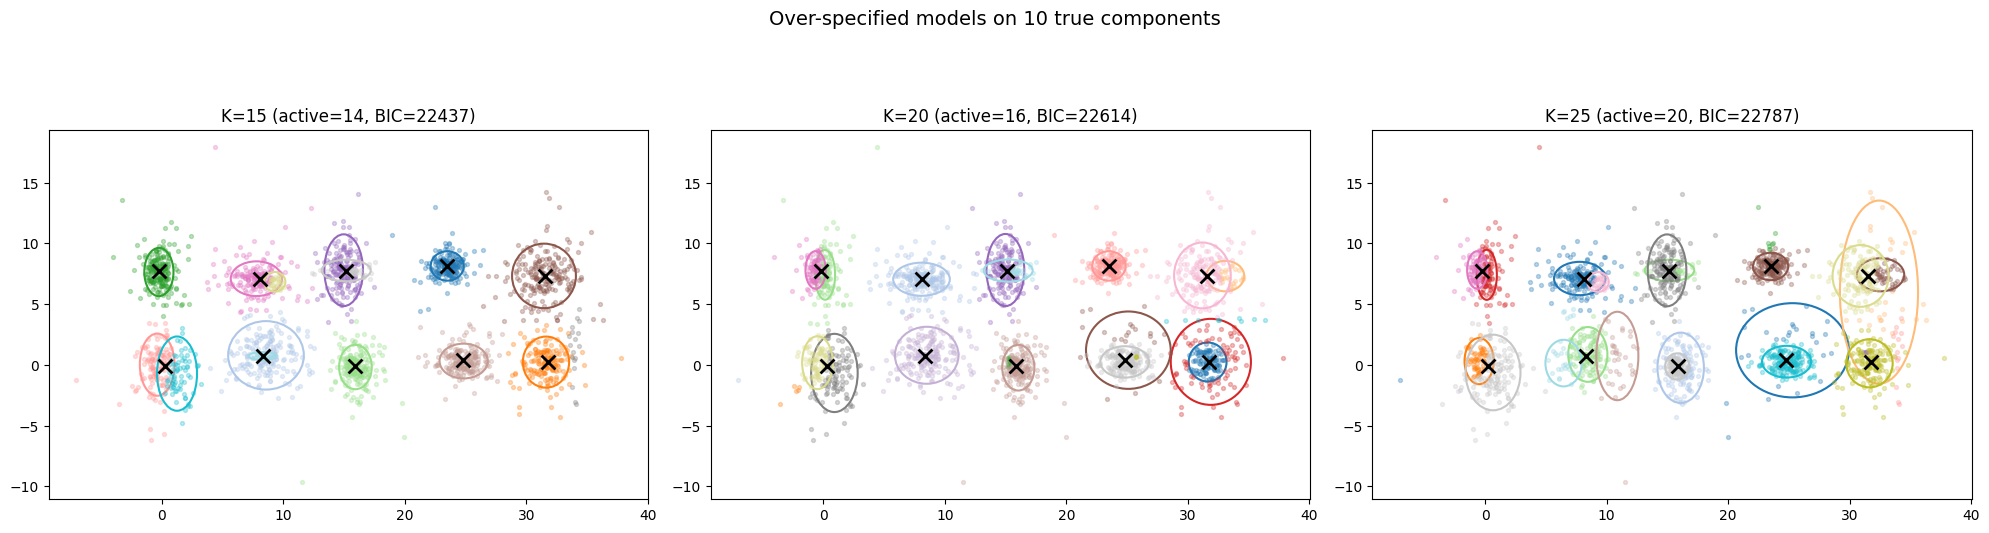


   K |        BIC | Active (>1%) | Converged
---------------------------------------------
  10 |      22264 |           10 |      True
  15 |      22437 |           14 |      True
  20 |      22614 |           16 |      True
  25 |      22787 |           20 |      True


In [8]:
K_values = [15, 20, 25]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

results = {}
for ax, K_fit in zip(axes, K_values):
    model = EMStudentMixture(n_components=K_fit, covariance_type='diag',
            fixed_df=False, max_iter=3000, tol=1e-7, n_init=3, random_state=42)
    model.fit(samples_10)
    pred = model.predict(samples_10)

    cmap = plt.cm.get_cmap('tab20', K_fit)
    for k in range(K_fit):
        mask = pred == k
        if np.sum(mask) > 0:
            ax.scatter(samples_10[mask, 0], samples_10[mask, 1], alpha=0.3, s=8,
                       c=[cmap(k)])
        # Only draw ellipses for active components
        if model.mix_weights_[k] > 0.01:
            plot_ellipse(ax, model.location_[k], model.scale_[:, k], n_std=2,
                         fill=False, edgecolor=cmap(k), linewidth=1.5)

    ax.scatter(true_locs[:, 0], true_locs[:, 1], marker='x', c='black',
               s=100, linewidths=2)

    active = np.sum(model.mix_weights_ > 0.01)
    bic = model.bic(samples_10)
    results[K_fit] = {'bic': bic, 'active': active, 'converged': model.converged_}
    ax.set_title(f'K={K_fit} (active={active}, BIC={bic:.0f})')
    ax.set_aspect('equal')

plt.suptitle('Over-specified models on 10 true components', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n{'K':>4} | {'BIC':>10} | {'Active (>1%)':>12} | {'Converged':>9}")
print("-" * 45)
print(f"{K_true:>4} | {model_10.bic(samples_10):>10.0f} | {np.sum(model_10.mix_weights_ > 0.01):>12} | {model_10.converged_!s:>9}")
for K_fit in K_values:
    r = results[K_fit]
    print(f"{K_fit:>4} | {r['bic']:>10.0f} | {r['active']:>12} | {r['converged']!s:>9}")

## 8. Ten Components — Exact Match (High-dim M=10, 50)

Same 10-component setup but in higher dimensions. Bar plots compare
true vs fitted per-dimension variances for a selected component.

M=10: Active=10/10, Converged=True, Mean rel err=0.098, Max rel err=0.347
M=50: Active=10/10, Converged=True, Mean rel err=0.083, Max rel err=0.329


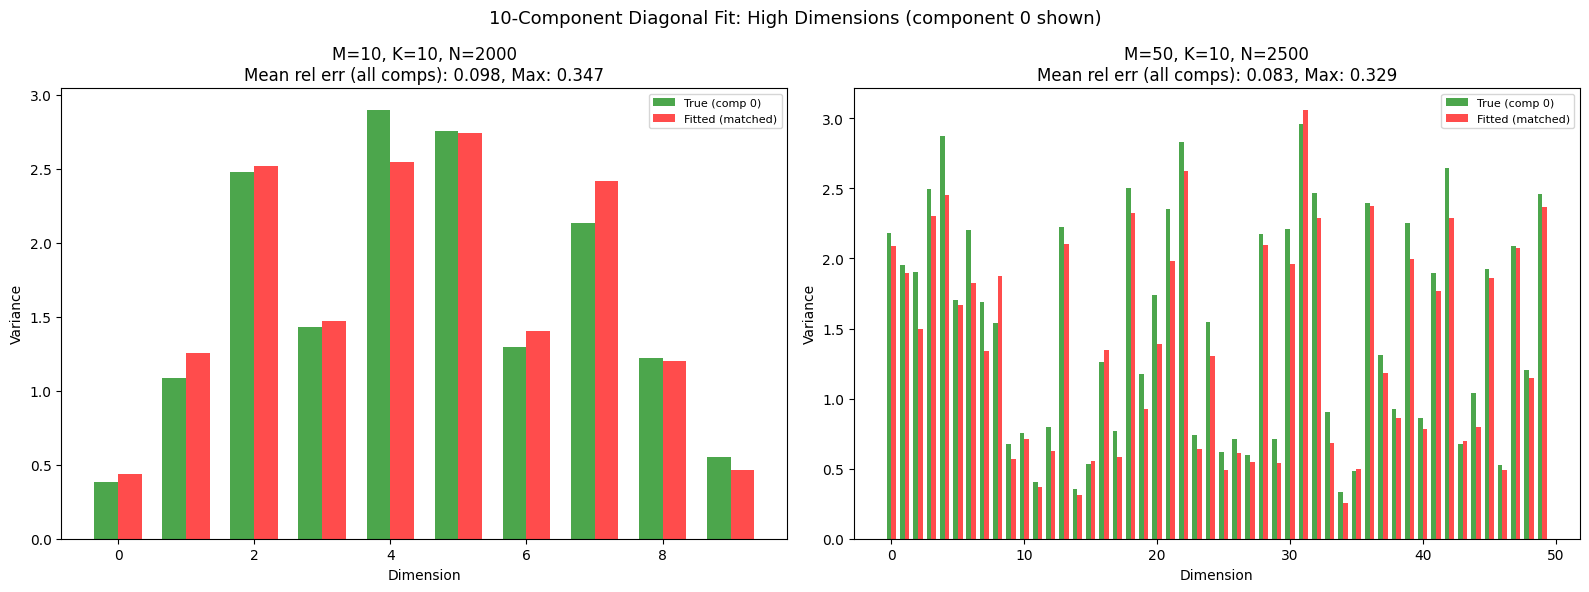

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, M in zip(axes, [10, 50]):
    np.random.seed(42)
    K_true = 10
    df = 4.0
    N_per = max(200, 5 * M)

    # Well-separated locations in M dimensions
    true_locs_hd = np.random.uniform(-10, 10, (K_true, M))
    true_vars_hd = np.random.uniform(0.3, 3.0, (M, K_true))

    all_samples_hd = []
    for k in range(K_true):
        s = scipy.stats.multivariate_t.rvs(true_locs_hd[k], np.diag(true_vars_hd[:, k]),
                                            df=df, size=N_per)
        all_samples_hd.append(s)
    samples_hd = np.vstack(all_samples_hd)

    model_hd = EMStudentMixture(n_components=K_true, covariance_type='diag',
            fixed_df=False, max_iter=3000, tol=1e-7, n_init=3, random_state=42)
    model_hd.fit(samples_hd)

    # Match fitted to true components by nearest location
    from scipy.spatial.distance import cdist
    dist_matrix = cdist(true_locs_hd, model_hd.location_)
    # Greedy matching
    matched = {}
    used = set()
    for _ in range(K_true):
        i, j = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
        while i in matched or j in used:
            dist_matrix[i, j] = np.inf
            i, j = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
        matched[i] = j
        used.add(j)
        dist_matrix[i, :] = np.inf
        dist_matrix[:, j] = np.inf

    # Average relative error across all components and dimensions
    all_true = np.hstack([true_vars_hd[:, k] for k in range(K_true)])
    all_fit = np.hstack([model_hd.scale_[:, matched[k]] for k in range(K_true)])
    mean_rel_err = np.mean(np.abs(all_fit - all_true) / all_true)
    max_rel_err = np.max(np.abs(all_fit - all_true) / all_true)

    # Show bar plot for component 0
    k_show = 0
    j_show = matched[k_show]
    dims = np.arange(M)
    width = 0.35
    ax.bar(dims - width/2, true_vars_hd[:, k_show], width, alpha=0.7,
           color='green', label='True (comp 0)')
    ax.bar(dims + width/2, model_hd.scale_[:, j_show], width, alpha=0.7,
           color='red', label='Fitted (matched)')
    ax.set_title(f'M={M}, K=10, N={N_per*K_true}\n'
                 f'Mean rel err (all comps): {mean_rel_err:.3f}, Max: {max_rel_err:.3f}')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Variance')
    ax.legend(fontsize=8)

    active = np.sum(model_hd.mix_weights_ > 0.01)
    print(f"M={M}: Active={active}/{K_true}, Converged={model_hd.converged_}, "
          f"Mean rel err={mean_rel_err:.3f}, Max rel err={max_rel_err:.3f}")

plt.suptitle('10-Component Diagonal Fit: High Dimensions (component 0 shown)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Ten True Modes — Over-specified K=15, 20, 25 (High-dim M=10)

Same 10-component high-dimensional data, fit with more components than needed.
BIC should favor K near the true value.

K=10: BIC=     82384, Active=10/10, Converged=True
K=15: BIC=     82823, Active=13/15, Converged=True
K=20: BIC=     83162, Active=15/20, Converged=True
K=25: BIC=     83518, Active=17/25, Converged=True


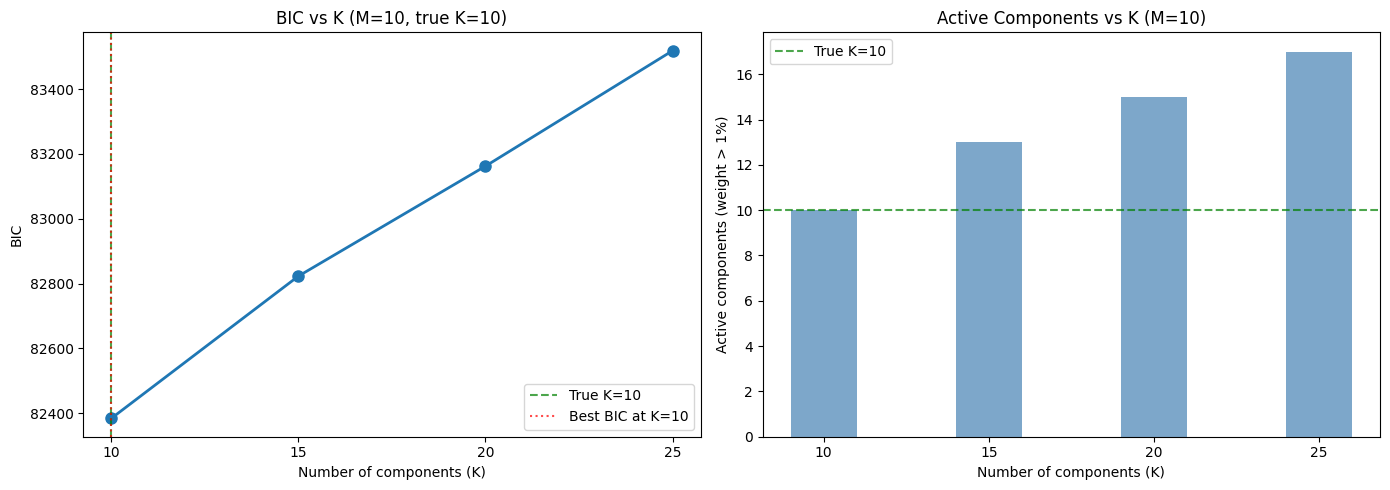

In [10]:
np.random.seed(42)
M = 10
K_true = 10
df = 4.0
N_per = 200

true_locs_hd10 = np.random.uniform(-10, 10, (K_true, M))
true_vars_hd10 = np.random.uniform(0.3, 3.0, (M, K_true))

all_samples_hd10 = []
for k in range(K_true):
    s = scipy.stats.multivariate_t.rvs(true_locs_hd10[k], np.diag(true_vars_hd10[:, k]),
                                        df=df, size=N_per)
    all_samples_hd10.append(s)
samples_hd10 = np.vstack(all_samples_hd10)

K_test = [10, 15, 20, 25]
bic_values = []
active_counts = []

for K_fit in K_test:
    model = EMStudentMixture(n_components=K_fit, covariance_type='diag',
            fixed_df=False, max_iter=3000, tol=1e-7, n_init=3, random_state=42)
    model.fit(samples_hd10)
    bic_val = model.bic(samples_hd10)
    active = np.sum(model.mix_weights_ > 0.01)
    bic_values.append(bic_val)
    active_counts.append(active)
    print(f"K={K_fit:>2}: BIC={bic_val:>10.0f}, Active={active:>2}/{K_fit}, "
          f"Converged={model.converged_}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BIC vs K
ax1.plot(K_test, bic_values, 'o-', markersize=8, linewidth=2)
ax1.axvline(x=K_true, color='green', linestyle='--', alpha=0.7, label=f'True K={K_true}')
best_K = K_test[np.argmin(bic_values)]
ax1.axvline(x=best_K, color='red', linestyle=':', alpha=0.7, label=f'Best BIC at K={best_K}')
ax1.set_xlabel('Number of components (K)')
ax1.set_ylabel('BIC')
ax1.set_title(f'BIC vs K (M={M}, true K={K_true})')
ax1.legend()
ax1.set_xticks(K_test)

# Active components vs K
ax2.bar(K_test, active_counts, color='steelblue', alpha=0.7, width=2)
ax2.axhline(y=K_true, color='green', linestyle='--', alpha=0.7, label=f'True K={K_true}')
ax2.set_xlabel('Number of components (K)')
ax2.set_ylabel('Active components (weight > 1%)')
ax2.set_title(f'Active Components vs K (M={M})')
ax2.legend()
ax2.set_xticks(K_test)

plt.tight_layout()
plt.show()